=== HTTPS-Only Analysis ===

All Sites Error Count and Percent by Country:
      Country  Error Count  Error Percent
   southkorea          118          11.24
    singapore          100           9.52
        india           62           5.90
  southafrica           60           5.71
        spain           57           5.43
 unitedstates           50           9.52
       canada           49           4.67
      germany           48           4.57
    australia           45           4.29
       brazil           38           3.62

Overall Metrics (All Sites):
1. Total Number of Error Sites over total crawled sites instance: 627/(19*525=9,975): 6.29%
2. Total Unique Error Sites over total unique sites instance: 453/(525*10=5,250): 8.63%

Country-Specific Error Count and Percent by Country:
      Country  Error Count  Error Percent
   southkorea           90          17.14
 unitedstates           50           9.52
    singapore           47           8.95
        india           40     

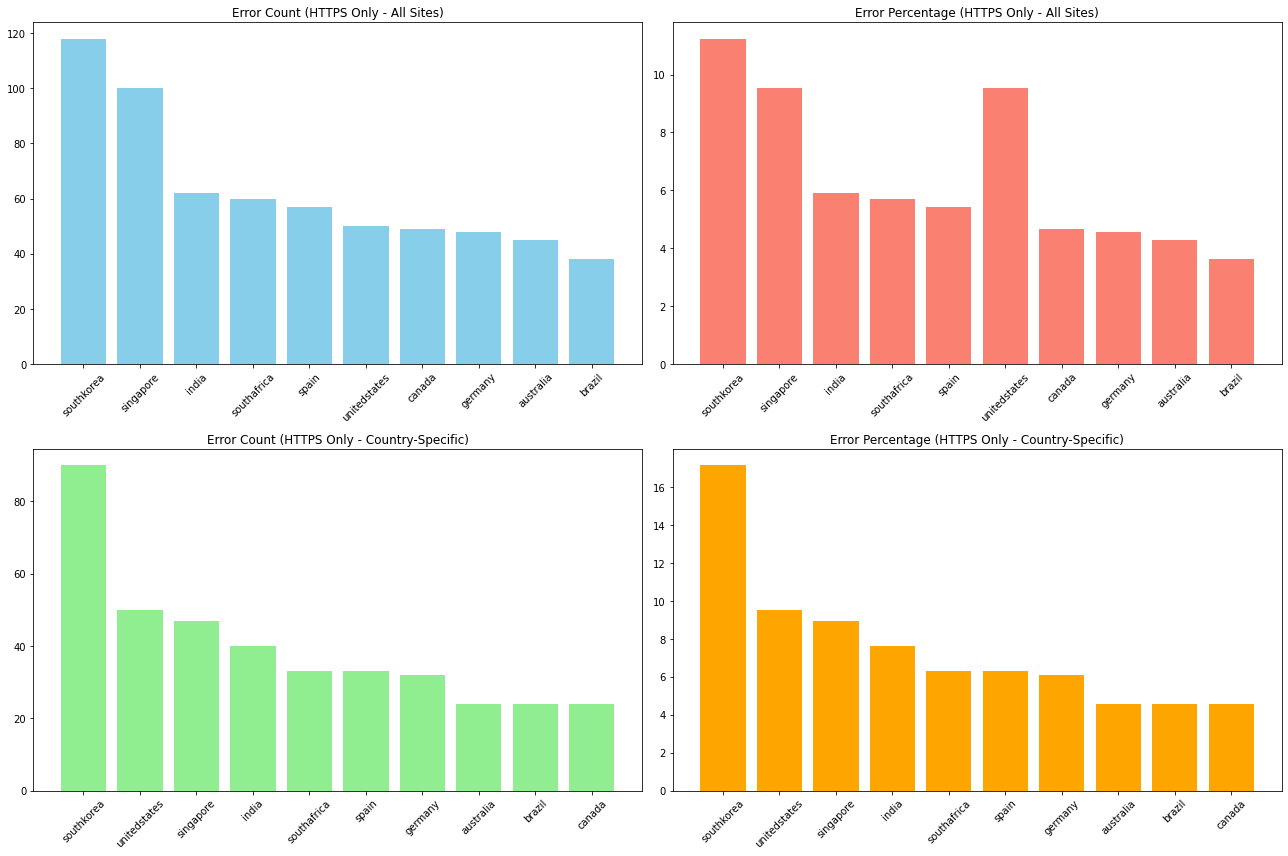

In [2]:
import os
from pathlib import Path
import re
import json
import pandas as pd
import matplotlib.pyplot as plt

# ================================================
# Configuration and Helper Functions
# ================================================
# Make the notebook robust to being launched from the repo root,
# analysis_scripts, or this subfolder in VS Code/Jupyter.
current_dir = Path.cwd().resolve()
repo_root = next(
    (
        path for path in [current_dir, *current_dir.parents]
        if (path / "analysis_scripts").exists() and (path / "analysis_data").exists()
    ),
    current_dir,
)
os.chdir(repo_root / "analysis_scripts")

entries_dir = '../analysis_data/entries'
error_log_dir = '../analysis_data/error-logging'
http_recrawl_dir = '../analysis_data/http_recrawl'
crawl_list_dir = '../analysis_data/crawl_list'

# "Ground truth" denominators per your instructions
TOTAL_CRAWLED_SITES_INSTANCE = 9975  # 9*525 + 10*525
TOTAL_UNIQUE_SITES_INSTANCE  = 5250  # 525*10

def normalize_site(site):
    """
    Remove protocol (http/https), leading 'www.', 
    and any trailing slash, then lowercase.
    """
    # Remove protocol
    site = re.sub(r'^https?://', '', site, flags=re.IGNORECASE)
    # Remove leading "www."
    site = re.sub(r'^www\.', '', site, flags=re.IGNORECASE)
    # Remove trailing slash
    site = site.rstrip('/')
    return site.lower()

# Load country-specific top sites, normalized
country_top_sites = {}
for filename in os.listdir(crawl_list_dir):
    if filename.endswith('-top-525.csv'):
        country = filename.split('-')[0].lower()
        df = pd.read_csv(os.path.join(crawl_list_dir, filename))
        # Normalize each domain from the CSV
        country_top_sites[country] = set(
            normalize_site(str(x)) for x in df.iloc[:, 0].dropna()
        )

def is_country_specific(site, country):
    """
    Check if the normalized version of `site`
    is in the set of top sites for `country`.
    """
    return normalize_site(site) in country_top_sites.get(country, set())

def process_error_data(error_data, country):
    """
    Returns:
      all_sites: list of all error sites from JSON
      cs_sites:  subset of error sites that are 'country-specific' 
                 to the given country
    """
    all_sites = []
    cs_sites = []
    for error_type, sites in error_data.items():
        for site in sites:
            all_sites.append(site)
            if is_country_specific(site, country):
                cs_sites.append(site)
    return all_sites, cs_sites

def calculate_per_country_rates(error_counts, total_sites_map):
    """
    Calculates the per-country error *percent*:
        count / total_sites_for_that_country * 100
    """
    return {
        c: (cnt / total_sites_map[c]) * 100 
        for c, cnt in error_counts.items()
    }

def plot_analysis(df_all, df_cs, title_suffix):
    fig, axs = plt.subplots(2, 2, figsize=(18, 12))
    
    # All sites plots
    axs[0,0].bar(df_all['Country'], df_all['Error Count'], color='skyblue')
    axs[0,0].set_title(f'Error Count ({title_suffix} - All Sites)')
    axs[0,1].bar(df_all['Country'], df_all['Error Percent'], color='salmon')
    axs[0,1].set_title(f'Error Percentage ({title_suffix} - All Sites)')
    
    # Country-specific plots
    axs[1,0].bar(df_cs['Country'], df_cs['Error Count'], color='lightgreen')
    axs[1,0].set_title(f'Error Count ({title_suffix} - Country-Specific)')
    axs[1,1].bar(df_cs['Country'], df_cs['Error Percent'], color='orange')
    axs[1,1].set_title(f'Error Percentage ({title_suffix} - Country-Specific)')
    
    for ax in axs.flat:
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()


# ================================================
# Cell 1: HTTPS Only Analysis
# ================================================
# Initialize trackers
https_all = {'counts': {}, 'unique': set()}
https_cs = {'counts': {}, 'unique': set()}

# We'll store for each country how many sites we consider total 
# for the "all sites" scenario (non-US = 1050, US=525)
country_totals = {'unitedstates': 525}
default_total = 1050  # For non-US countries: top525 + US's 525

# Process HTTPS errors
for filename in os.listdir(error_log_dir):
    if filename.endswith('.json'):
        # e.g., "error_unitedstates_https.json" => country = "unitedstates"
        country = filename.split('_')[1].lower()
        with open(os.path.join(error_log_dir, filename)) as f:
            data = json.load(f)
        
        all_sites, cs_sites = process_error_data(data, country)
        
        # All sites tracking
        https_all['counts'][country] = len(all_sites)
        https_all['unique'].update(all_sites)
        
        # Country-specific tracking
        https_cs['counts'][country] = len(cs_sites)
        https_cs['unique'].update(cs_sites)

# Build the dict of total sites for per-country denominators
total_sites_all = {c: country_totals.get(c, default_total) for c in https_all['counts']}
# For the country-specific analysis, each country only has 525 "native" top sites
total_sites_cs = {c: 525 for c in https_cs['counts']}

# Calculate the per-country error rates
rates_all = calculate_per_country_rates(https_all['counts'], total_sites_all)
rates_cs  = calculate_per_country_rates(https_cs['counts'], total_sites_cs)

# Summed total errors and total unique
tot_all = sum(https_all['counts'].values())
uni_all = len(https_all['unique'])

tot_cs = sum(https_cs['counts'].values())
uni_cs = len(https_cs['unique'])

# For the overall rate, use the ground-truth denominators
ovr_all = (tot_all / TOTAL_CRAWLED_SITES_INSTANCE) * 100
uni_rate_all = (uni_all / TOTAL_UNIQUE_SITES_INSTANCE) * 100

# For country-specific "overall" we often also divide by 9975, but 
# you currently do:
ovr_cs = (tot_cs / TOTAL_UNIQUE_SITES_INSTANCE) * 100
uni_rate_cs = (uni_cs / TOTAL_UNIQUE_SITES_INSTANCE) * 100

# Create DataFrames
df_all = pd.DataFrame([
    (c, https_all['counts'][c], rates_all[c]) 
    for c in https_all['counts']
], columns=['Country', 'Error Count', 'Error Percent']).sort_values('Error Count', ascending=False)

df_cs = pd.DataFrame([
    (c, https_cs['counts'][c], rates_cs[c]) 
    for c in https_cs['counts']
], columns=['Country', 'Error Count', 'Error Percent']).sort_values('Error Count', ascending=False)

# Round 'Error Percent' to two decimals
df_all['Error Percent'] = df_all['Error Percent'].round(2)
df_cs['Error Percent']  = df_cs['Error Percent'].round(2)

# Print results
print("=== HTTPS-Only Analysis ===\n")
print("All Sites Error Count and Percent by Country:")
print(df_all.to_string(index=False))
print("\nOverall Metrics (All Sites):")
print(f"1. Total Number of Error Sites over total crawled sites instance: "
      f"{tot_all}/(19*525=9,975): {ovr_all:.2f}%")
print(f"2. Total Unique Error Sites over total unique sites instance: "
      f"{uni_all}/(525*10=5,250): {uni_rate_all:.2f}%")

print("\nCountry-Specific Error Count and Percent by Country:")
print(df_cs.to_string(index=False))
print("\nOverall Metrics (Country-Specific):")
print(f"1. Total Number of Error Sites over total crawled sites instance: "
      f"{tot_cs}/(525*10=5,250): {ovr_cs:.2f}%")
print(f"2. Total Unique Error Sites over total unique sites instance: "
      f"{uni_cs}/(525*10=5,250): {uni_rate_cs:.2f}%")

# Plot results
plot_analysis(df_all, df_cs, 'HTTPS Only')





=== Combined HTTPS + HTTP Analysis ===

All Sites Error Count and Percent by Country:
      Country  Error Count  Error Percent
    singapore           94           8.95
        india           57           5.43
   southkorea           49           4.67
        spain           49           4.67
 unitedstates           49           9.33
  southafrica           48           4.57
    australia           41           3.90
      germany           41           3.90
       brazil           30           2.86
       canada           29           2.76

Overall Metrics (All Sites):
1. Total Number of Error Sites over total crawled sites instance: 487/(19*525=9,975): 4.88%
2. Total Unique Error Sites over total unique sites instance: 322/(525*10=5,250): 6.13%

Country-Specific Error Count and Percent by Country:
      Country  Error Count  Error Percent
 unitedstates           49           9.33
    singapore           42           8.00
        india           36           6.86
      germany      

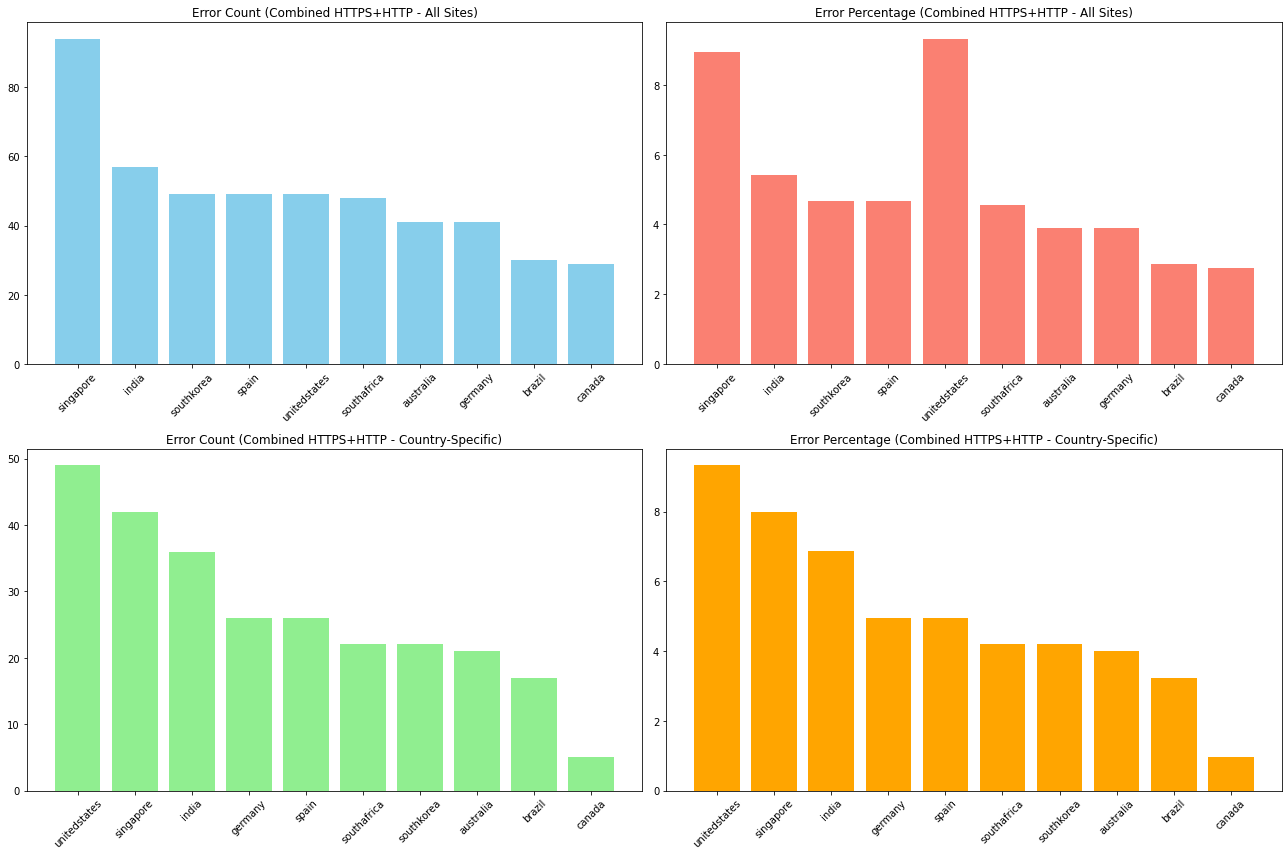

CSV file 'country_specific_error_count.csv' has been saved.


In [ ]:
# ================================================
# Cell 2: Combined HTTPS + HTTP Analysis
# ================================================

# Function to export a CSV table of country and error count
def store_csv_table(df, file_name):
    """
    Stores the given DataFrame to a CSV file with the specified file name.
    
    Parameters:
        df (pd.DataFrame): DataFrame containing at least 'Country' and 'Error Count' columns.
        file_name (str): Name of the output CSV file.
    """
    df.to_csv(file_name, index=False)
    print(f"CSV file '{file_name}' has been saved.")

combined_all = {'counts': {}, 'unique': set()}
combined_cs = {'counts': {}, 'unique': set()}

# Process original HTTPS errors (excluding InsecureCertificateError)
for filename in os.listdir(error_log_dir):
    if filename.endswith('.json'):
        country = filename.split('_')[1].lower()
        with open(os.path.join(error_log_dir, filename)) as f:
            data = {
                k: v for k, v in json.load(f).items() 
                if k != "InsecureCertificateError"
            }
        
        all_sites, cs_sites = process_error_data(data, country)
        
        # Initialize if missing
        if country not in combined_all['counts']:
            combined_all['counts'][country] = 0
        if country not in combined_cs['counts']:
            combined_cs['counts'][country] = 0
        
        combined_all['counts'][country] += len(all_sites)
        combined_all['unique'].update(all_sites)
        combined_cs['counts'][country] += len(cs_sites)
        combined_cs['unique'].update(cs_sites)

# Process HTTP recrawl errors
http_error_dir = os.path.join(http_recrawl_dir, 'error-logging')
for filename in os.listdir(http_error_dir):
    if filename.endswith('.json'):
        country = filename.split('_')[1].lower()
        with open(os.path.join(http_error_dir, filename)) as f:
            data = json.load(f)
        
        all_sites, cs_sites = process_error_data(data, country)
        
        # Initialize if missing
        if country not in combined_all['counts']:
            combined_all['counts'][country] = 0
        if country not in combined_cs['counts']:
            combined_cs['counts'][country] = 0
        
        combined_all['counts'][country] += len(all_sites)
        combined_all['unique'].update(all_sites)
        combined_cs['counts'][country] += len(cs_sites)
        combined_cs['unique'].update(cs_sites)

# Calculate per-country rates with the same denominators
rates_all_comb = calculate_per_country_rates(combined_all['counts'], total_sites_all)
rates_cs_comb  = calculate_per_country_rates(combined_cs['counts'], total_sites_cs)

tot_all_comb = sum(combined_all['counts'].values())
uni_all_comb = len(combined_all['unique'])

tot_cs_comb = sum(combined_cs['counts'].values())
uni_cs_comb = len(combined_cs['unique'])

# Overall with the ground-truth denominators
ovr_all_comb     = (tot_all_comb / TOTAL_CRAWLED_SITES_INSTANCE) * 100
uni_rate_all_comb= (uni_all_comb / TOTAL_UNIQUE_SITES_INSTANCE)  * 100

ovr_cs_comb      = (tot_cs_comb / TOTAL_UNIQUE_SITES_INSTANCE)  * 100
uni_rate_cs_comb = (uni_cs_comb / TOTAL_UNIQUE_SITES_INSTANCE)   * 100

# Create DataFrames
df_all_comb = pd.DataFrame([
    (c, combined_all['counts'][c], rates_all_comb[c]) 
    for c in combined_all['counts']
], columns=['Country', 'Error Count', 'Error Percent']).sort_values('Error Count', ascending=False)

df_cs_comb = pd.DataFrame([
    (c, combined_cs['counts'][c], rates_cs_comb[c]) 
    for c in combined_cs['counts']
], columns=['Country', 'Error Count', 'Error Percent']).sort_values('Error Count', ascending=False)

df_all_comb['Error Percent'] = df_all_comb['Error Percent'].round(2)
df_cs_comb['Error Percent']  = df_cs_comb['Error Percent'].round(2)

# Print results
print("\n=== Combined HTTPS + HTTP Analysis ===\n")
print("All Sites Error Count and Percent by Country:")
print(df_all_comb.to_string(index=False))
print("\nOverall Metrics (All Sites):")
print(f"1. Total Number of Error Sites over total crawled sites instance: "
      f"{tot_all_comb}/(19*525=9,975): {ovr_all_comb:.2f}%")
print(f"2. Total Unique Error Sites over total unique sites instance: "
      f"{uni_all_comb}/(525*10=5,250): {uni_rate_all_comb:.2f}%")

print("\nCountry-Specific Error Count and Percent by Country:")
print(df_cs_comb.to_string(index=False))
print("\nOverall Metrics (Country-Specific):")
print(f"1. Total Number of Error Sites over total crawled sites instance: "
      f"{tot_cs_comb}/(525*10=5,250): {ovr_cs_comb:.2f}%")
print(f"2. Total Unique Error Sites over total unique sites instance: "
      f"{uni_cs_comb}/(525*10=5,250): {uni_rate_cs_comb:.2f}%")

# Plot results
plot_analysis(df_all_comb, df_cs_comb, 'Combined HTTPS+HTTP')

# Save the country-specific error count as a CSV file.
# This CSV will include only the 'Country' and 'Error Count' columns.
store_csv_table(df_cs_comb[['Country', 'Error Count']], 'country_specific_error_count.csv')
